### 1️⃣ Project Title

# Building a YouTube Data Dashboard with Streamlit

## Objective
Analyze YouTube channel performance using the Global YouTube Statistics dataset and create an interactive dashboard with Streamlit.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Streamlit

### 2️⃣ Import Libraries

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### 3️⃣ Load Dataset

In [26]:
df = pd.read_csv(
    "../data/Global YouTube Statistics.csv",
    encoding="latin1"
)

df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


### 4️⃣ Dataset Overview

In [27]:
df.shape

(995, 28)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                         994 non-n

In [29]:
df.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00000,9.950000e+02,9.950000e+02,995.000000,9.940000e+02,879.000000,962.000000,9.390000e+02,995.000000,9.950000e+02,...,9.950000e+02,6.580000e+02,990.000000,990.000000,872.000000,8.720000e+02,872.000000,8.720000e+02,872.000000,872.000000
mean,498.00000,2.298241e+07,1.103954e+10,9187.125628,5.542489e+05,386.053470,745.719335,1.756103e+08,36886.148281,5.898078e+05,...,7.081814e+06,3.490791e+05,2012.630303,15.746465,63.627752,4.303873e+08,9.279278,2.242150e+08,26.632783,-14.128146
std,287.37606,1.752611e+07,1.411084e+10,34151.352254,1.362782e+06,1232.244746,1944.386561,4.163782e+08,71858.724092,1.148622e+06,...,1.379704e+07,6.143554e+05,4.512503,8.777520,26.106893,4.727947e+08,4.888354,1.546874e+08,20.560533,84.760809
min,1.00000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,249.50000,1.450000e+07,4.288145e+09,194.500000,3.230000e+02,11.000000,27.000000,2.013750e+07,2700.000000,4.350000e+04,...,5.217500e+05,1.000000e+05,2009.000000,8.000000,36.300000,8.335541e+07,5.270000,5.590832e+07,20.593684,-95.712891
50%,498.00000,1.770000e+07,7.760820e+09,729.000000,9.155000e+02,51.000000,65.500000,6.408500e+07,13300.000000,2.127000e+05,...,2.600000e+06,2.000000e+05,2013.000000,16.000000,68.000000,3.282395e+08,9.365000,2.706630e+08,37.090240,-51.925280
75%,746.50000,2.460000e+07,1.355470e+10,2667.500000,3.584500e+03,123.000000,139.750000,1.688265e+08,37900.000000,6.068000e+05,...,7.300000e+06,4.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.00000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.000000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


### 5️⃣ Missing Values

In [30]:
df.isnull().sum()

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                                5
created_date 

### 6️⃣ Data Cleaning

In [31]:
df.columns = df.columns.str.strip()

df.fillna(0, inplace=True)

### 7️⃣ Top 10 YouTubers by Subscribers

In [32]:
top_subscribers = (
    df.sort_values(
        by="subscribers",
        ascending=False
    )
    .head(10)
)

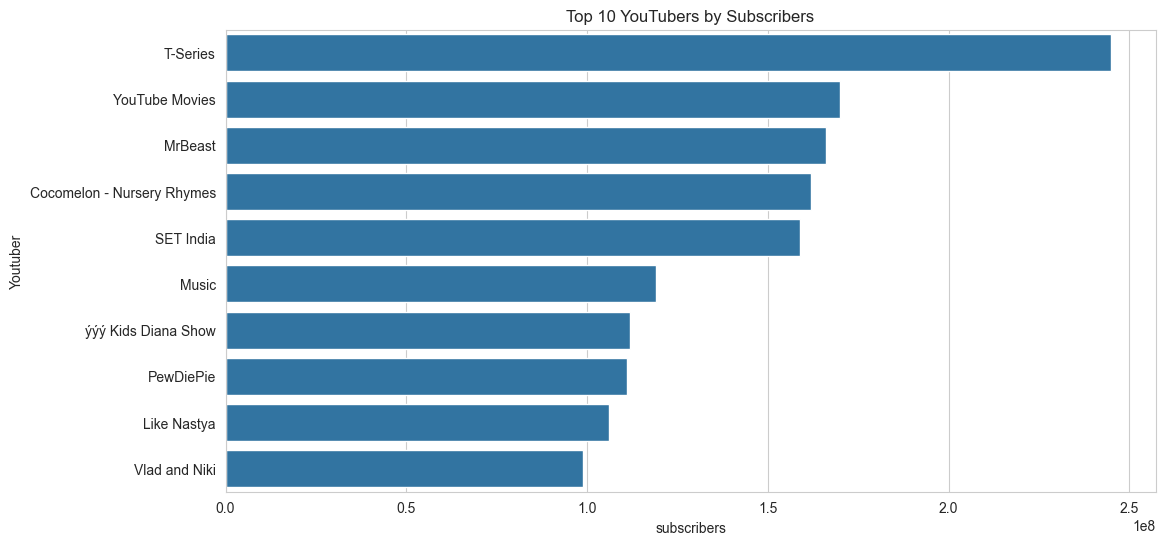

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_subscribers,
    x="subscribers",
    y="Youtuber"
)

plt.title("Top 10 YouTubers by Subscribers")

plt.savefig("../images/top_channels.png")

plt.show()

### 8️⃣ Top Categories

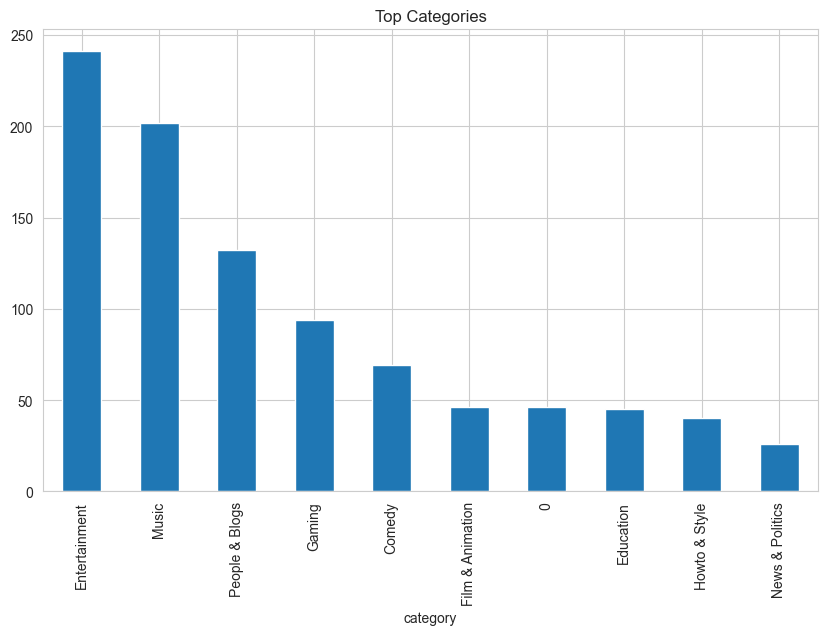

In [34]:
plt.figure(figsize=(10,6))

df["category"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Categories")

plt.savefig("../images/category_analysis.png")

plt.show()

### 9️⃣ Country-wise Distribution

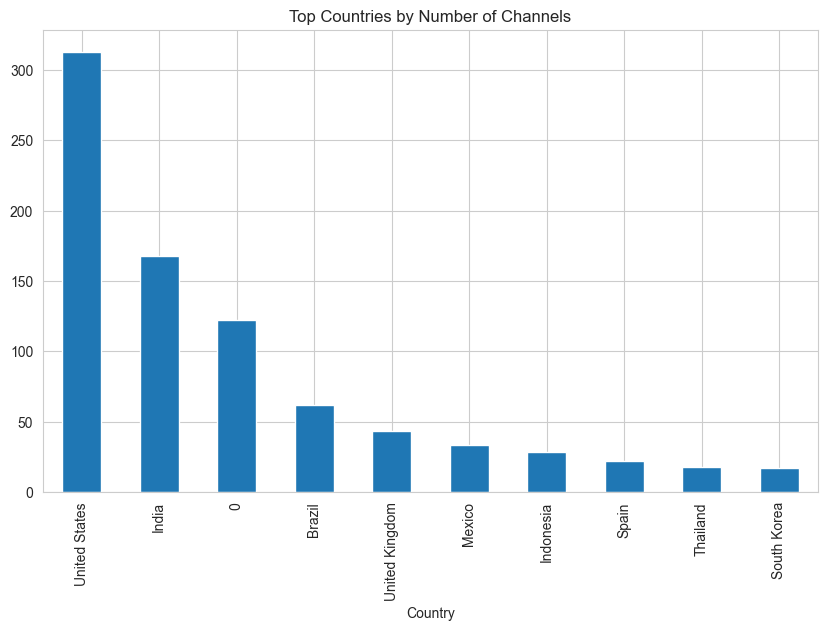

In [35]:
plt.figure(figsize=(10,6))

df["Country"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Countries by Number of Channels")

plt.savefig("../images/country_analysis.png")

plt.show()

### 🔟 Subscribers vs Video Views

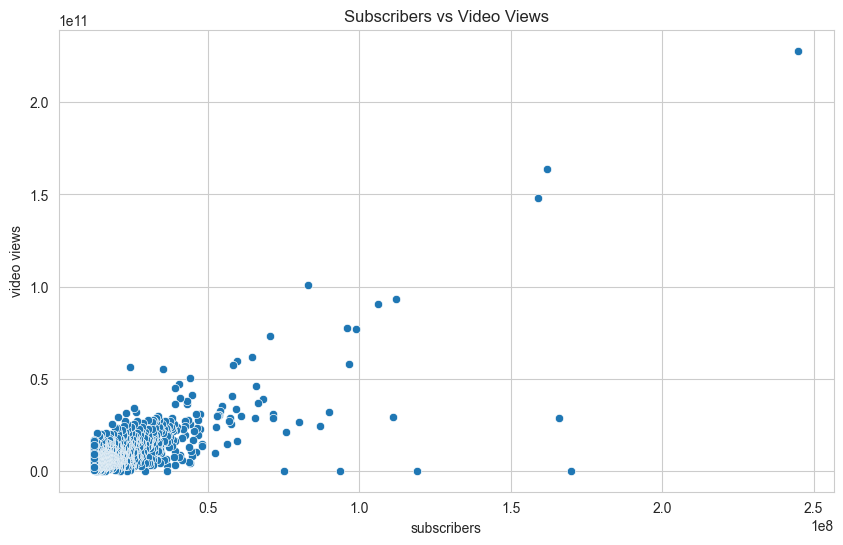

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="subscribers",
    y="video views"
)

plt.title(
    "Subscribers vs Video Views"
)

plt.savefig("../images/subscribers_vs_views.png")

plt.show()

### 1️⃣1️⃣ Earnings Analysis

In [37]:
top_earnings = (
    df.sort_values(
        by="highest_yearly_earnings",
        ascending=False
    )
    .head(10)
)

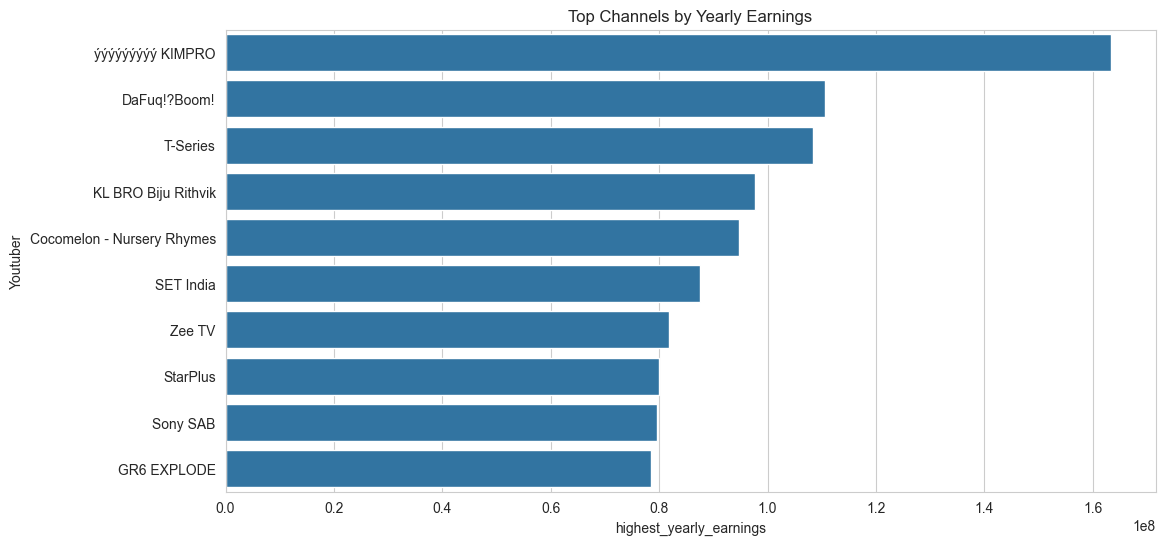

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_earnings,
    x="highest_yearly_earnings",
    y="Youtuber"
)

plt.title(
    "Top Channels by Yearly Earnings"
)

plt.savefig("../images/earnings_analysis.png")

plt.show()

### 1️⃣2️⃣ Correlation Heatmap

In [39]:
numeric_cols = [
    "subscribers",
    "video views",
    "uploads",
    "highest_yearly_earnings"
]

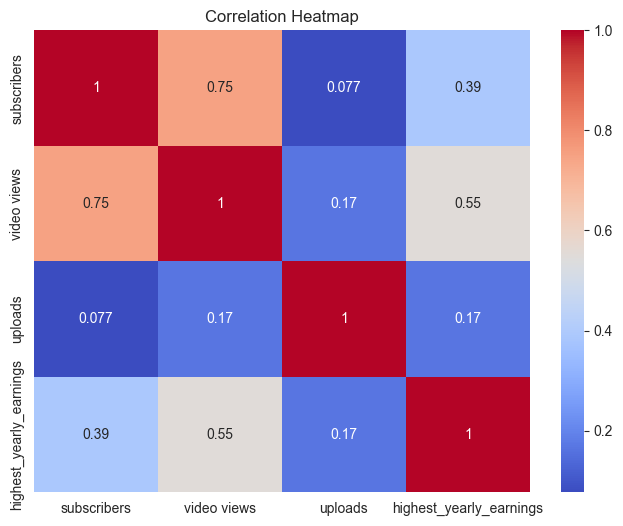

In [40]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png")

plt.show()

### 1️⃣3️⃣ Performance Score (Advanced)

In [41]:
df["Performance_Score"] = (
    df["subscribers"] * 0.4
    +
    df["video views"] * 0.4
    +
    df["uploads"] * 0.2
)

In [42]:
top_performance = (
    df.sort_values(
        by="Performance_Score",
        ascending=False
    )
    .head(10)
)

top_performance[
    ["Youtuber","Performance_Score"]
]

,Youtuber,Performance_Score
0,T-Series,9.129800e+10
3,Cocomelon - Nursery Rhymes,6.566480e+10
4,SET India,5.926362e+10
15,Sony SAB,4.043321e+10
6,ýýý Kids Diana Show,3.734362e+10
8,Like Nastya,3.623402e+10
11,WWE,3.100980e+10
9,Vlad and Niki,3.091163e+10
21,Zee TV,2.928385e+10
26,Colors TV,2.463023e+10


## Key Insights

- T-Series has the highest subscriber count.
- Music and Entertainment are the dominant categories.
- Subscriber count strongly correlates with video views.
- Top earning channels also tend to have higher subscriber counts.
- India and the United States have the largest number of popular channels.

## Conclusion

The analysis revealed significant relationships between subscribers, video views, uploads, and earnings. The insights obtained from this dataset can help understand channel growth patterns and content performance on YouTube.